In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import string
import json

import spacy
from spacy.tokens import Doc

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Preprocess Data
- ignore and jump to "load data" if already saved preprocessed data to "news_tokenized.csv"

In [ ]:
news = pd.read_json(r"News_Category_Dataset_v3.json", lines=True)

In [ ]:
news.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


## cleaning

### drop irrelevant cols

In [ ]:
news.drop(["link", "authors", "date"], inplace = True, axis = 1)

### drop empty rows

In [ ]:
def removeEmptyLine(df,col_name):
    df.replace("", pd.NA, inplace = True)
    df.dropna(subset=[col_name], inplace=True)
    return df

In [ ]:
news = removeEmptyLine(news, "headline")
news = removeEmptyLine(news,"short_description")

In [ ]:
news.head()

,headline,category,short_description
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha..."
3,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to..."
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...


In [ ]:
news.shape

(189814, 3)

### filter 20% of each categories

In [ ]:
news.loc[news['category'] == "THE WORLDPOST", 'category'] = "WORLDPOST"

<Axes: xlabel='category'>

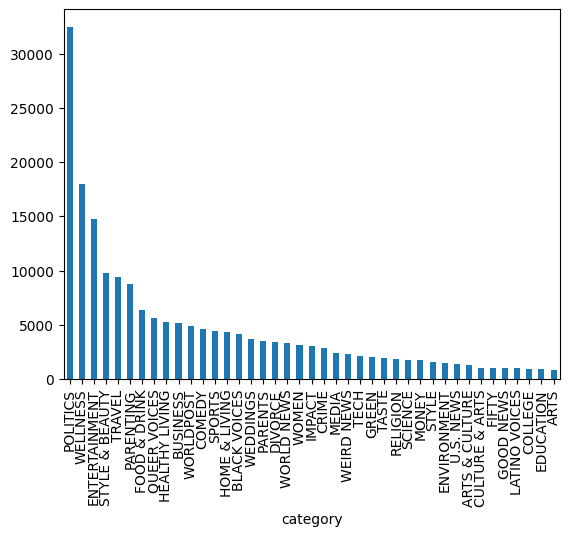

In [ ]:
news.category.value_counts().plot(kind="bar")

In [ ]:
# print category size descending
min_size = news.category.value_counts().min()
min_size

863

In [ ]:
# filter to include 20% of each category
news_filtered = news.groupby("category", group_keys=False).sample(frac=0.2, random_state=42)

<Axes: xlabel='category'>

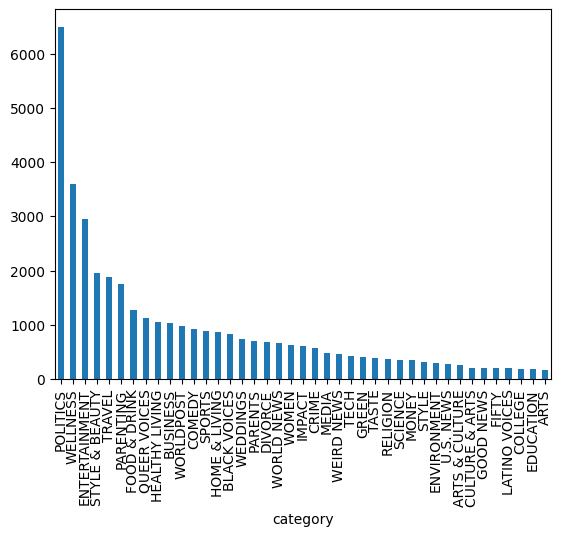

In [ ]:
news_filtered.category.value_counts().plot(kind="bar")

## encoding

### tokenize text

In [ ]:
import spacy # NLP library
import spacy.cli # to download language models
spacy.cli.download("en_core_web_lg") # download english LLM
nlp = spacy.load("en_core_web_lg") # load the english LLM

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!pip install swifter
import swifter # to accelerate df operations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16507 sha256=b2d6af714542389927953a05c42b0146c954f9216f6bdc19c2cac983b0f60cb5
  Stored in directory: /root/.cache/pip/wheels/ef/7f/bd/9bed48f078f3ee1fa75e0b29b6e0335ce1cb03a38d3443b3a3
Successfully built swifter


In [ ]:
def tokenize(text):
    doc = nlp(text)
    processed_tokens = []
    for token in doc:
        if not (token.is_stop or token.is_punct or token.like_num):  # Skip stopwords, punctuation, numbers
            processed_tokens.append(token.lemma_.lower())  # Lemmatization + lowercase

    return " ".join(processed_tokens)

In [ ]:
news_tokenized = news_filtered.copy()
news_tokenized["text"] = news_tokenized["headline"] + " " + news_tokenized["short_description"]
news_tokenized.drop(["headline", "short_description"], inplace = True, axis = 1)

In [ ]:
news_tokenized["text"] = news_tokenized["text"].swifter.apply(tokenize)

Pandas Apply:   0%|          | 0/37960 [00:00<?, ?it/s]

In [ ]:
# save to csv
news_tokenized.to_csv("news_tokenized.csv", index=False)

In [ ]:
news_tokenized.head()

,category,text
125846,ARTS,thing know cindy sherman look untitled film wo...
119579,ARTS,trip bountiful foote play look past inspiratio...
97429,ARTS,dream care painting capture innocence childhoo...
101571,ARTS,w souleo dance exhibition celebrate first look...
107850,ARTS,high def selfie arts humanities technology fac...
